# DDSM-ACGAN — benign vs malignant mammography augmentation on Colab

Applies the same ACGAN + VGG16 architecture from the CovidGAN reconstruction to **CBIS-DDSM mammography ROI patches**, classifying **benign vs malignant** rather than COVID vs Normal. Same pipeline shape: train an ACGAN on real ROIs → generate a synthetic pool → train the detection CNN with and without synthetic augmentation → compare.

**Before running:** `Runtime > Change runtime type > T4 GPU`. This notebook expects:
- A zipped folder of pre-extracted CBIS-DDSM ROI patches on your Drive, named like `P_<patient>_<LEFT|RIGHT>_<CC|MLO>_<mass|calcification>_<n>.png`.
- The four standard CBIS-DDSM case-description CSVs (mass/calc × train/test) on your Drive.

Repo: https://github.com/MayaHayat/generative_models — this notebook lives in `DDSM-ACGAN-Pytorch/`.

In [1]:
!nvidia-smi

Sat Aug 22 10:40:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Mount Drive, clone the repo, install light dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!git clone https://github.com/MayaHayat/generative_models.git
%cd generative_models/DDSM-ACGAN-Pytorch
!pip install -q scikit-learn matplotlib pillow wandb

Cloning into 'generative_models'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 118 (delta 70), reused 76 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 7.90 MiB | 31.59 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/generative_models/DDSM-ACGAN-Pytorch


**Optional: Weights & Biases logging.** Skip this cell (and drop `--wandb` from the commands below) if you don't want it — everything still runs and prints to stdout either way. If you do want it, grab an API key from wandb.ai/authorize.

In [4]:

import wandb
wandb.login()  # paste your API key when prompted

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Unzip the ROI patches

Adjust the path to wherever your `ddsm_rois.zip` actually lives on Drive.

In [5]:
ROI_ZIP = '/content/drive/MyDrive/Thesis/ddsm_rois.zip'
!unzip -q "{ROI_ZIP}" -d /content/ddsm_rois
!find /content/ddsm_rois -maxdepth 3 -type d

/content/ddsm_rois
/content/ddsm_rois/rois


The unzip usually produces a top-level folder (e.g. `/content/ddsm_rois/rois`) containing the PNG files directly. If the listing above shows a different nesting, update `ROI_DIR` in the next cell to match.

In [6]:
ROI_DIR = '/content/ddsm_rois/rois'
!ls {ROI_DIR} | head -5
!ls {ROI_DIR} | wc -l

P_00001_LEFT_CC_mass_1.png
P_00001_LEFT_MLO_mass_1.png
P_00004_LEFT_CC_mass_1.png
P_00004_LEFT_MLO_mass_1.png
P_00004_RIGHT_MLO_mass_1.png
3568


## 3. Point at the CBIS-DDSM metadata CSVs

These carry the benign/malignant pathology labels and the official train/test split — adjust the folder if yours differs.

In [7]:
CSV_DIR = '/content/drive/MyDrive/Thesis/tabular-dataset'
MASS_TRAIN_CSV = f'{CSV_DIR}/mass_case_description_train_set.csv'
MASS_TEST_CSV  = f'{CSV_DIR}/mass_case_description_test_set.csv'
CALC_TRAIN_CSV = f'{CSV_DIR}/calc_case_description_train_set.csv'
CALC_TEST_CSV  = f'{CSV_DIR}/calc_case_description_test_set.csv'

## 4. Build the manifest (join ROIs to pathology labels)

**Read the match-rate report this prints carefully.** If it's low, the CSV column names or ROI filenames don't match what this script assumes — check the printed sample of unmatched files before trusting anything downstream.

In [8]:
!python prepare_ddsm.py --roi-dir {ROI_DIR} --mass-train-csv {MASS_TRAIN_CSV} --mass-test-csv {MASS_TEST_CSV} --out-dir data

Matched 1696/1696 ROI files to a pathology label (100.0%).

Matched breakdown:
  train  benign     681
  train  malignant  637
  test   benign     231
  test   malignant  147

Wrote data/manifest.csv


## 5. Train the ACGAN — generator + discriminator

`GAN_EPOCHS = 2000` mirrors CovidGAN's setting. Start with something like 50 to sanity-check the whole pipeline before committing hours to it — and note how much smaller/larger your train set is than CovidGAN's 932 images, which changes how long each epoch actually takes.

**Checkpoints save directly to Drive** (`GAN_OUT_DIR`) rather than local Colab disk, since this is the one multi-hour step where losing progress to a session disconnect actually hurts. If a session drops mid-run, re-run cells 1-4 to get back to a working environment, then re-run this cell unchanged — it auto-detects and resumes from the latest checkpoint already on Drive instead of restarting.

### GAN Training - mass only - part 1

In [ ]:
GAN_EPOCHS = 300  # try e.g. 50 for a quick smoke test first
GAN_OUT_DIR = '/content/drive/MyDrive/ddsm_acgan_runs/fixed_gan_mass'

import glob
checkpoints = sorted(glob.glob(f'{GAN_OUT_DIR}/checkpoints/ddsm_acgan_epoch*.pt'))
resume_flag = f'--resume {checkpoints[-1]}' if checkpoints else ''
print('resuming from:', checkpoints[-1] if checkpoints else '(fresh start, no checkpoint found)')

!python train_gan.py --manifest data/manifest.csv --out-dir {GAN_OUT_DIR} --epochs {GAN_EPOCHS} --batch-size 64 --lr 2e-4 --beta1 0.5 --sample-every 25 --checkpoint-every 50 {resume_flag} --wandb --wandb-project ddsm-acgan --wandb-run-name gan

resuming from: /content/drive/MyDrive/ddsm_acgan_runs/fixed_gan_mass/checkpoints/ddsm_acgan_epoch0100.pt
device: cuda  architecture: baseline
training images: 1318
G params: 22,247,542  D params: 1,644,832
resumed from /content/drive/MyDrive/ddsm_acgan_runs/fixed_gan_mass/checkpoints/ddsm_acgan_epoch0100.pt at epoch 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run fil0gesf (0.0s)
wandb: ⣻ setting up run fil0gesf (0.0s)
wandb: ⣽ setting up run fil0gesf (0.0s)
wandb: ⣾ setting up run fil0gesf (0.0s)
wandb: ⣷ setting up run fil0gesf (0.5s)
wandb: ⣯ setting up run fil0gesf (0.5s)
wandb: ⣟ setting up run fil0gesf (0.5s)
wandb: ⡿ setting up run fil0gesf (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is sa

## 6. Sample the trained generator into a synthetic pool

Check the class counts printed by `prepare_ddsm.py` above (step 4) and set these to roughly balance or oversample the minority class -- CBIS-DDSM is not perfectly balanced between benign and malignant, unlike the defaults below which assume a rough 600/600 split.

In [22]:
!rm -rf /content/generative_models/DDSM-ACGAN-Pytorch/data/synthetic/

In [23]:
GAN_OUT_DIR = '/content/drive/MyDrive/ddsm_acgan_runs/fixed_gan_mass'

!python generate_synthetic.py --checkpoint /content/drive/MyDrive/ddsm_acgan_runs/fixed_gan_mass/checkpoints/ddsm_acgan_final.pt --out-dir data/synthetic --n-benign 300 --n-malignant 300 --seed 1

wrote 300 synthetic benign images to data/synthetic/benign
wrote 300 synthetic malignant images to data/synthetic/malignant


# 7. CNN-AD — detection CNN trained on real ROIs only (baseline)

In [24]:
!python train_classifier.py --manifest data/manifest.csv --mode ad --out-dir runs/cnn_ad --epochs 25 --batch-size 16 --lr 1e-3 --wandb --wandb-project ddsm-acgan --wandb-group exp1 --seed 1

device: cuda  mode: ad  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch/wandb/run-20260822_112834-quas5r8e
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cnn-ad
wandb: ⭐️ View project at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan
wandb: 🚀 View run at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan/runs/quas5r8e
train: 1318 real (actual-data only)
params: 14,747,650 total, 32,962 trainable (unfreeze_blocks=0, head_bn=False)
epoch 1/25  loss=0.6885  train_acc=54.55%


## 8. CNN-SA — same CNN, trained on real + synthetic ROIs

In [25]:
!python train_classifier.py --manifest data/manifest.csv --mode sa --synthetic-dir data/synthetic --out-dir runs/cnn_sa --epochs 25 --batch-size 16 --lr 1e-3 --wandb --wandb-project ddsm-acgan --wandb-group exp1 --seed 1

device: cuda  mode: sa  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch/wandb/run-20260822_113145-hjozkvn0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cnn-sa
wandb: ⭐️ View project at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan
wandb: 🚀 View run at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan/runs/hjozkvn0
train: 1318 real + 600 synthetic = 1918
params: 14,747,650 total, 32,962 trainable (unfreeze_blocks=0, head_bn=False)
epoch 1/25  loss=0.5758  train_acc=66.68%
epoch 2/25  loss=0.4730  train_ac

## 9. Improved GANS - part 2 with VGG training

### GAN Training

In [10]:
GAN_OUT_DIR = '/content/drive/MyDrive/ddsm_acgan_runs/gan_improved_2_mass_only'

import glob
checkpoints = sorted(glob.glob(f'{GAN_OUT_DIR}/checkpoints/ddsm_acgan_epoch*.pt'))
resume_flag = f'--resume {checkpoints[-1]}' if checkpoints else ''
print('resuming from:', checkpoints[-1] if checkpoints else '(fresh start, no checkpoint found)')

!python train_gan.py --manifest data/manifest.csv \
    --out-dir {GAN_OUT_DIR} \
    --epochs 600 --batch-size 64 --lr 2e-4 --beta1 0.5 \
    --sample-every 25 --checkpoint-every 50 --improved {resume_flag} \
    --wandb --wandb-project ddsm-acgan --wandb-run-name gan_improved_2_mass_only


resuming from: /content/drive/MyDrive/ddsm_acgan_runs/gan_improved_2_mass_only/checkpoints/ddsm_acgan_epoch0350.pt
device: cuda  architecture: improved
training images: 1318
G params: 16,046,326  D params: 1,643,840
resumed from /content/drive/MyDrive/ddsm_acgan_runs/gan_improved_2_mass_only/checkpoints/ddsm_acgan_epoch0350.pt at epoch 350
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run cugo455s (0.0s)
wandb: ⣻ setting up run cugo455s (0.0s)
wandb: ⣽ setting up run cugo455s (0.0s)
wandb: ⣾ setting up run cugo455s (0.0s)
wandb: ⣷ setting up run cugo455s (0.5s)
wandb: ⣯ setting up run cugo455s (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch

Preview the most recent sample grid:

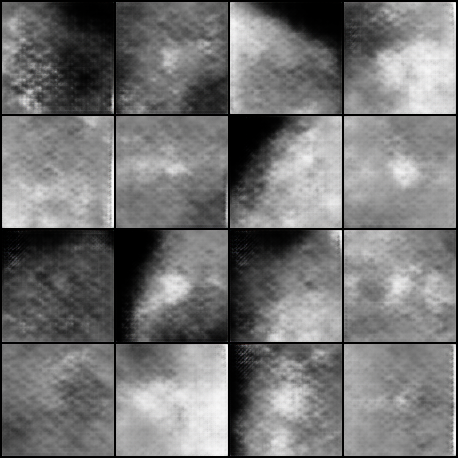

In [11]:
from pathlib import Path
from IPython.display import Image, display

latest = sorted(Path(f'{GAN_OUT_DIR}/samples').glob('epoch_*.png'))[-1]
display(Image(filename=str(latest)))

### VGG Training

In [26]:
!rm -rf /content/generative_models/DDSM-ACGAN-Pytorch/data/synthetic_improved/

In [27]:
!python generate_synthetic.py --checkpoint /content/drive/MyDrive/ddsm_acgan_runs/gan_improved_2_mass_only/checkpoints/ddsm_acgan_epoch0300.pt \
    --out-dir data/synthetic_improved --n-benign 300 --n-malignant 300 --improved --seed 1


wrote 300 synthetic benign images to data/synthetic_improved/benign
wrote 300 synthetic malignant images to data/synthetic_improved/malignant


In [28]:
!python train_classifier.py --manifest data/manifest.csv --mode sa \
    --synthetic-dir data/synthetic_improved --out-dir runs/cnn_sa_improved --epochs 25 --batch-size 16 --lr 1e-3 \
    --wandb --wandb-project ddsm-acgan --wandb-group exp3 --seed 1

device: cuda  mode: sa  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ Waiting for wandb.init()...
wandb: ⣯ Waiting for wandb.init()...
wandb: ⣟ Waiting for wandb.init()...
wandb: ⡿ Waiting for wandb.init()...
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ Waiting for wandb.init()...
wandb: ⣯ Waiting for wandb.init()...
wandb: ⣟ Waiting for wandb.init()...
wandb: ⡿ Waiting for wandb.init()...
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Wa

## 9.1 VGG Improvement

### AD (Real Data Only)

In [29]:
!python train_classifier.py --manifest data/manifest.csv --mode ad \
    --out-dir runs/cnn_ad_uf2 --epochs 25 --batch-size 16 --lr 1e-3 \
    --unfreeze-blocks 2 --head-bn --backbone-lr 1e-5 --seed 1 \
    --wandb --wandb-project ddsm-acgan --wandb-run-name cnn-ad-uf2 --wandb-group exp4


device: cuda  mode: ad  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch/wandb/run-20260822_113920-m53jdvq1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cnn-ad-uf2
wandb: ⭐️ View project at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan
wandb: 🚀 View run at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan/runs/m53jdvq1
train: 1318 real (actual-data only)
params: 14,747,778 total, 13,012,290 trainable (unfreeze_blocks=2, head_bn=True)
  differential lr: backbone=1e-05  

## SA (Both Synthetic and Real)

In [30]:
!python train_classifier.py --manifest data/manifest.csv --mode sa \
    --synthetic-dir data/synthetic --out-dir runs/cnn_sa_uf2 --epochs 25 --batch-size 16 --lr 1e-3 \
    --unfreeze-blocks 2 --head-bn --backbone-lr 1e-5 --seed 1 \
    --wandb --wandb-project ddsm-acgan --wandb-run-name cnn-sa-uf2 --wandb-group exp4


device: cuda  mode: sa  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch/wandb/run-20260822_114238-5y8ju407
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cnn-sa-uf2
wandb: ⭐️ View project at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan
wandb: 🚀 View run at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan/runs/5y8ju407
train: 1318 real + 600 synthetic = 1918
params: 14,747,778 total, 13,012,290 trainable (unfreeze_blocks=2, head_bn=True)
  differential lr: backbone=1e-05  head=0.001
epoch 1/25  loss=0.5186  train_acc=69.92%
epoch 2/25  loss=0.4184  train_acc=78.73%
e

In [31]:
!python train_classifier.py --manifest data/manifest.csv --mode sa \
    --synthetic-dir data/synthetic_improved --out-dir runs/cnn_sa_uf2_improved_gan --epochs 25 --batch-size 16 --lr 1e-3 \
    --unfreeze-blocks 2 --head-bn --backbone-lr 1e-5 --seed 1 \
    --wandb --wandb-project ddsm-acgan --wandb-run-name cnn-sa-uf2 --wandb-group exp4


device: cuda  mode: sa  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch/wandb/run-20260822_114630-tmhjvs29
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cnn-sa-uf2
wandb: ⭐️ View project at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan
wandb: 🚀 View run at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan/runs/tmhjvs29
train: 1318 real + 600 synthetic = 1918
params: 14,747,778 total, 13,012,290 trainable (unfreeze_blocks=2, head_bn=True)
  differential lr: backbone=1e-

## CHECK

In [32]:
!git pull

remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 10 (delta 8), reused 10 (delta 8), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 2.56 KiB | 875.00 KiB/s, done.
From https://github.com/MayaHayat/generative_models
   98e2887..3be9832  main       -> origin/main
Updating 98e2887..3be9832
Fast-forward
 DDSM-ACGAN-Pytorch/data_scarcity.py    |  1 +
 DDSM-ACGAN-Pytorch/multiseed.py        |  1 +
 DDSM-ACGAN-Pytorch/train_classifier.py | 23 +++++++++++++++++++++--
 DDSM-ACGAN-Pytorch/train_gan.py        | 14 ++++++++++++--
 4 files changed, 35 insertions(+), 4 deletions(-)


In [33]:
!python train_classifier.py --manifest data/manifest.csv --mode sa \
    --synthetic-dir data/synthetic --synthetic-only \
    --out-dir runs/probe_baseline --epochs 25 --unfreeze-blocks 2 --head-bn --seed 1 \
    --wandb --wandb-project ddsm-acgan --wandb-run-name probe-baseline-synth-only

!python train_classifier.py --manifest data/manifest.csv --mode sa \
    --synthetic-dir data/synthetic_improved --synthetic-only \
    --out-dir runs/probe_improved --epochs 25 --unfreeze-blocks 2 --head-bn --seed 1 \
    --wandb --wandb-project ddsm-acgan --wandb-run-name probe-improved-synth-only


device: cuda  mode: sa  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch/wandb/run-20260822_115022-14vh6zaj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run probe-baseline-synth-only
wandb: ⭐️ View project at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan
wandb: 🚀 View run at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan/runs/14vh6zaj
train: 600 synthetic ONLY (real data excluded -- fingerprint probe)
params: 14,747,778 total, 13,012,290 trainable (unfreeze_blocks=2, he

### CHECK EPOCH 600 IMPROVED

In [34]:
!python generate_synthetic.py --checkpoint /content/drive/MyDrive/ddsm_acgan_runs/gan_improved_2_mass_only/checkpoints/ddsm_acgan_epoch0600.pt \
    --out-dir data/synthetic_improved_epoch600 --n-benign 300 --n-malignant 300 --improved --seed 1

!python train_classifier.py --manifest data/manifest.csv --mode sa \
    --synthetic-dir data/synthetic_improved_epoch600 --synthetic-only \
    --out-dir runs/probe_improved --epochs 25 --unfreeze-blocks 2 --head-bn --seed 1 \
    --wandb --wandb-project ddsm-acgan --wandb-run-name probe-improved-synth-only

wrote 300 synthetic benign images to data/synthetic_improved_epoch600/benign
wrote 300 synthetic malignant images to data/synthetic_improved_epoch600/malignant
device: cuda  mode: sa  seed: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: maya-hayat (maya-hayat-ariel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /content/generative_models/DDSM-ACGAN-Pytorch/wandb/run-20260822_120217-oy40wpcg
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run probe-improved-synth-only
wandb: ⭐️ View project at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan
wandb: 🚀 View run at https://wandb.ai/maya-hayat-ariel-university/ddsm-acgan/runs/oy40wpcg
train: 600 syn

## 10. Compare CNN-AD vs CNN-SA

In [15]:
print('=== CNN-AD (real ROIs only) ===')
print(Path('runs/cnn_ad/metrics.txt').read_text())
print()
print('=== CNN-SA (real + synthetic) ===')
print(Path('runs/cnn_sa_improved/metrics.txt').read_text())

=== CNN-AD (real ROIs only) ===


FileNotFoundError: [Errno 2] No such file or directory: 'runs/cnn_ad/metrics.txt'

CNN-SA confusion matrix


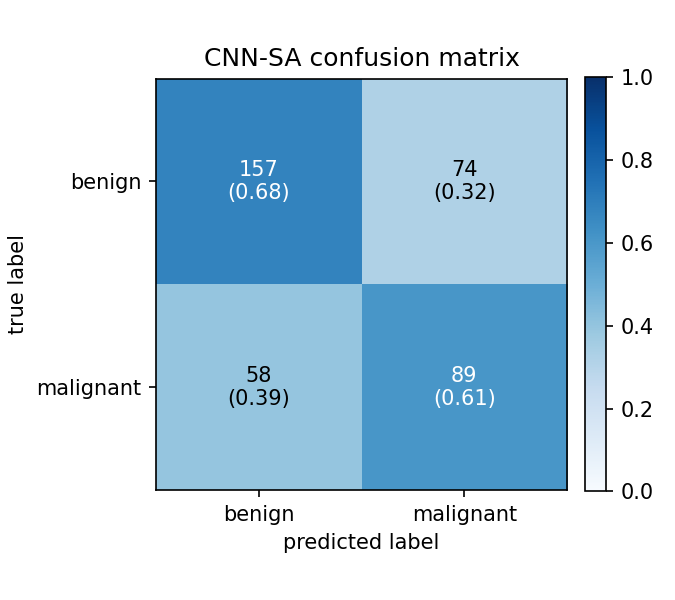

PCA of penultimate-layer features (real vs. synthetic)


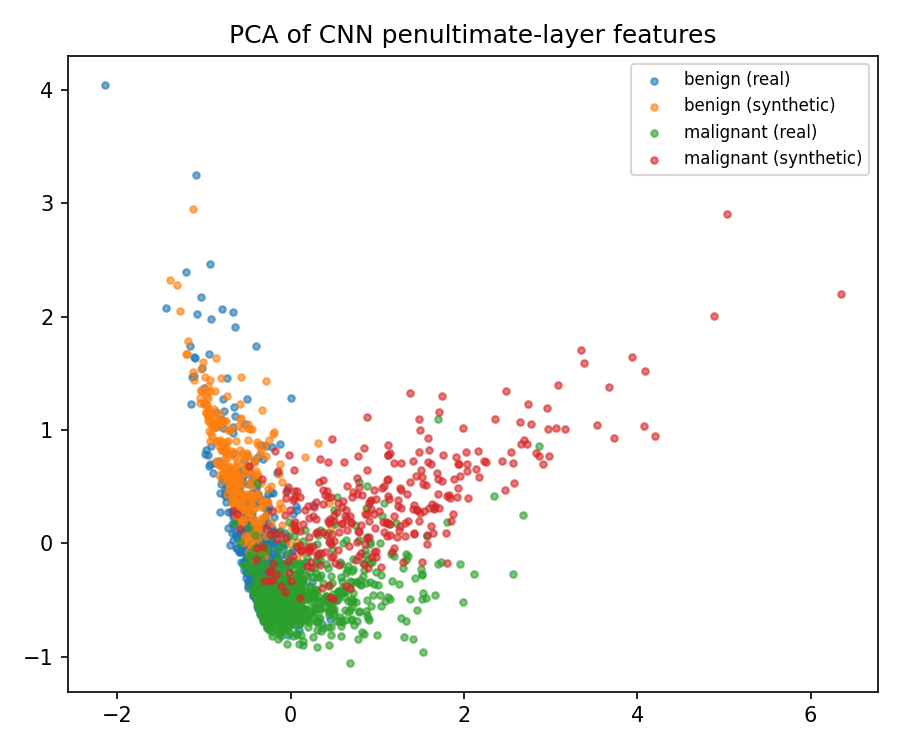

In [16]:
from IPython.display import Image, display

# print('CNN-AD confusion matrix')
# display(Image(filename='runs/cnn_ad/confusion_matrix.png'))
print('CNN-SA confusion matrix')
display(Image(filename='runs/cnn_sa_improved/confusion_matrix.png'))
print('PCA of penultimate-layer features (real vs. synthetic)')
display(Image(filename='runs/cnn_sa_improved/pca.png'))

## 11. (Optional) Persist classifier results to Google Drive

The GAN checkpoints/samples are already on Drive (step 5 wrote there directly) — this just saves the classifier runs and manifest, which are cheap to regenerate but convenient to keep.

In [21]:
!mkdir -p /content/drive/MyDrive/ddsm_acgan_runs
!cp -r runs/cnn_ad runs/cnn_sa /content/drive/MyDrive/ddsm_acgan_runs/
!cp data/manifest.csv /content/drive/MyDrive/ddsm_acgan_runs/